# Deconvolution

In [7]:
import matplotlib.pyplot as plt
import skimage.io as io
from skimage.color import rgb2gray
import numpy as np
from skimage.util import random_noise
from skimage.filters import gaussian
from scipy.ndimage import convolve
from numpy.fft import fft2, fftshift, ifftshift, ifft2
from skimage.restoration import wiener
from skimage.metrics import mean_squared_error

## Image

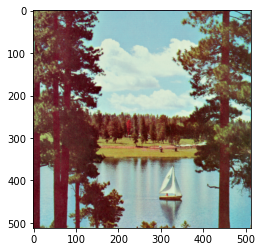

In [8]:
img = io.imread('4.2.06.tiff')
io.imsave("sailboat.png", img)

plt.figure()
plt.imshow(img, cmap="gray")
plt.show()

## Observation

/tmp/ipykernel_63749/2590564470.py:2: FutureWarning: The behavior of rgb2gray will change in scikit-image 0.19. Currently, rgb2gray allows 2D grayscale image to be passed as inputs and leaves them unmodified as outputs. Starting from version 0.19, 2D arrays will be treated as 1D images with 3 channels.
  img = rgb2gray(img)


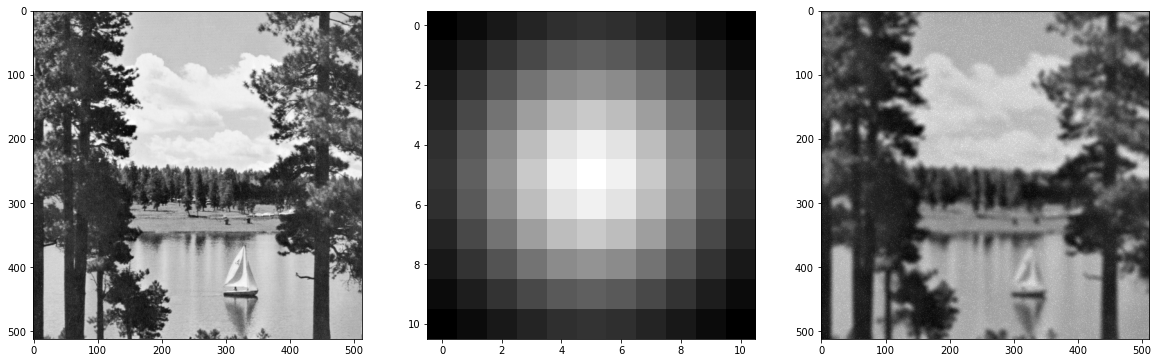

In [28]:
# Original image
img = rgb2gray(img)

# PSF
sigma = 3
c = 5
M = 2*c+1
delta = np.zeros((M,M)) / M**2
delta[c,c] = 1
psf = gaussian(delta, sigma=sigma)

# Noise
void = np.zeros(img.shape)
noise = random_noise(void, 'gaussian', var=.002)

# Observation
blurred = convolve(img, psf)
obs = blurred + noise

# Display
fig, axs = plt.subplots(1,3, figsize=(20,10))
axs[0].imshow(img, cmap="gray")
axs[1].imshow(psf, cmap="gray")
axs[2].imshow(obs, cmap="gray")
plt.show()

## Deconvolution functions

In [29]:
# Filtre inverse
def inverse_filter(obs, psf):
    F = fft2(obs)
    H = fft2(psf, F.shape)
    X = F/H
    return np.real(ifft2(X))
    
# Filtre inverse
def truncated_inverse_filter(obs, psf, fc):
    N, _ = obs.shape
    F = fft2(obs)
    H = fft2(psf, F.shape)
    X = F/H
    start = np.round(N*fc).astype(int)
    stop  = np.round(N*(1-fc)).astype(int)
    X[start:stop,:] = 0
    X[:,start:stop] = 0
    return np.real(ifft2(X))
    
# Filtre inverse
def wiener_filter(obs, psf, lbd):
    return wiener(obs, psf, lbd)

## Display & save

In [30]:
def display(images, filename=None):
    I = len(images)
    fig, axs = plt.subplots(1, I, figsize=(20,10))
    for i in range(I):
        img, title = images[i]
        axs[i].imshow(img, cmap="gray")
        axs[i].set_title(title, fontsize=20)
        axs[i].set_xticks([])
        axs[i].set_yticks([])
    if filename != None:
        plt.savefig(filename, bbox_inches='tight')
    plt.show()

## Deconvolution methods

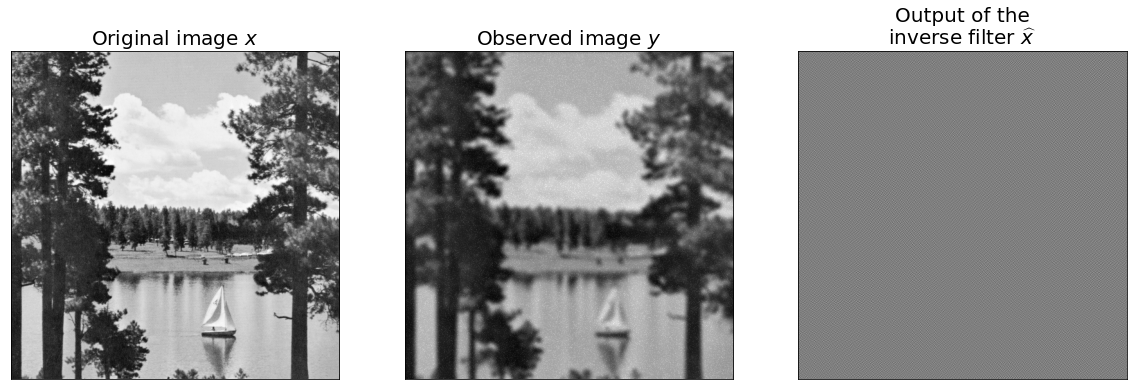

In [32]:
rec = inverse_filter(obs, psf)
images = [
    [img, "Original image $x$"],
    [obs, "Observed image $y$"],
    [rec, "Output of the\ninverse filter $\widehat{x}$"]
]
display(images, "inverse-filter.svg")

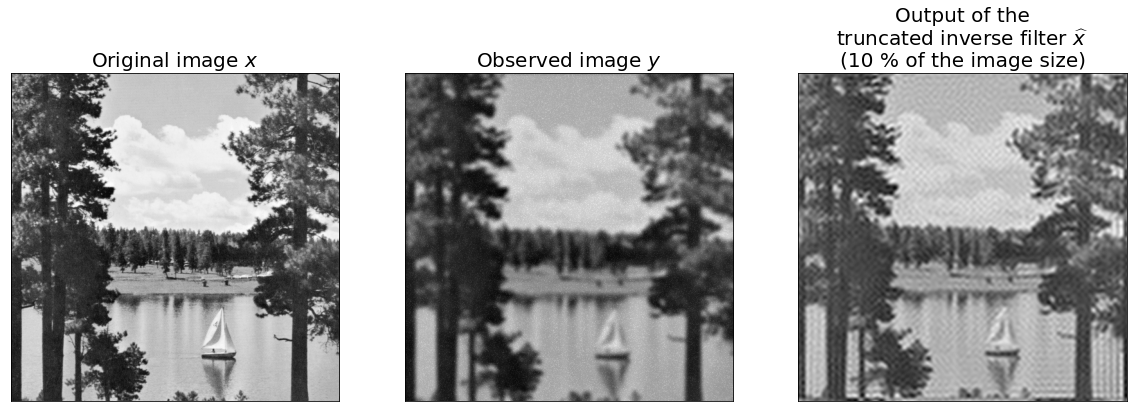

In [7]:
pc = .1
rec = truncated_inverse_filter(obs, psf, pc)
images = [
    [img, "Original image $x$"],
    [obs, "Observed image $y$"],
    [rec, f"Output of the\ntruncated inverse filter $\widehat{{x}}$\n({pc*100:.0f} % of the image size)"]
]
display(images, "truncated-inverse-filter.svg")

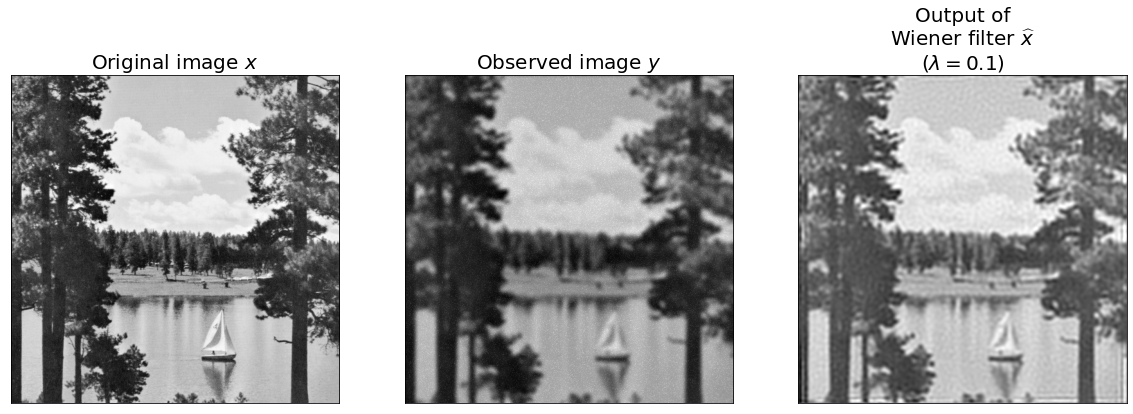

In [8]:
lbd = .1
rec = wiener_filter(obs, psf, lbd)
images = [
    [img, "Original image $x$"],
    [obs, "Observed image $y$"],
    [rec, f"Output of\nWiener filter $\widehat{{x}}$\n($\lambda = {lbd}$)"]
]
display(images)

## Truncated inverse & Wiener filters, with the best parameters

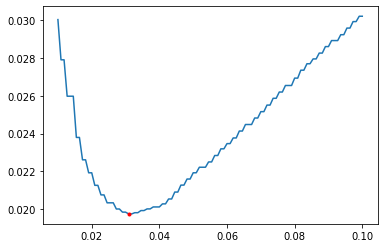

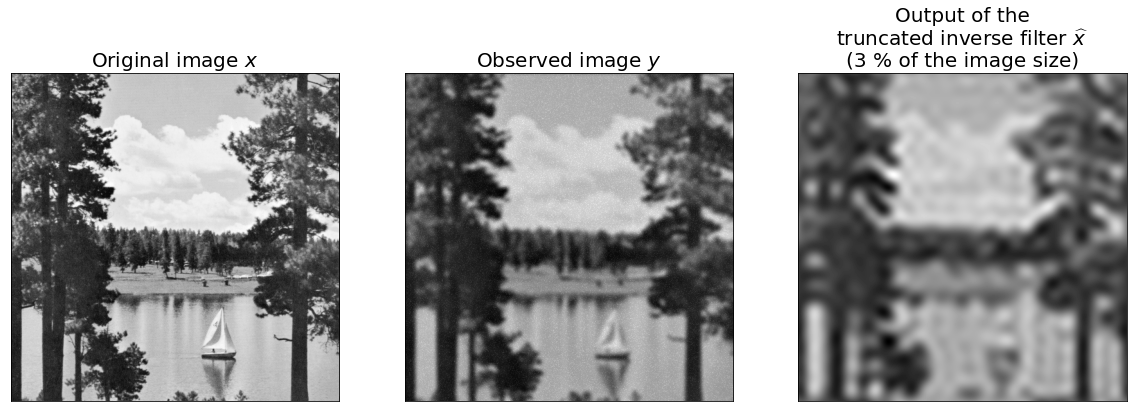

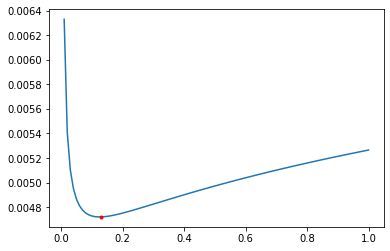

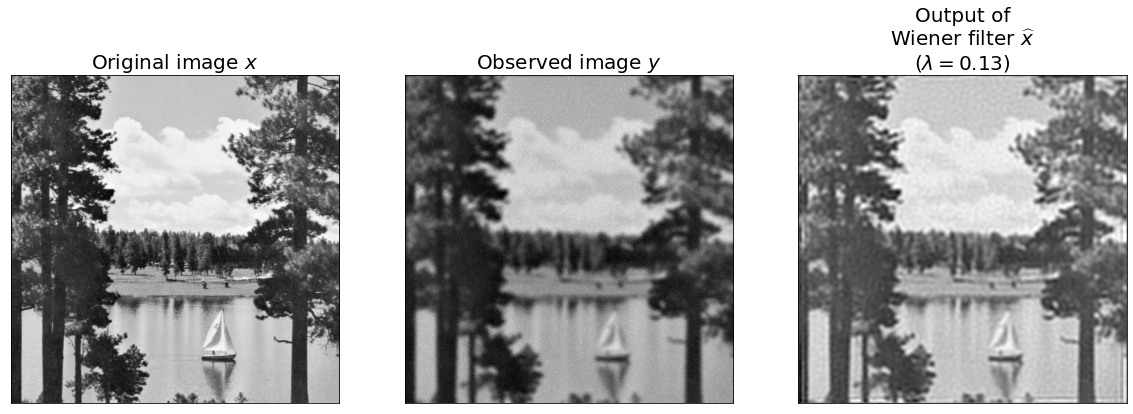

In [9]:
# Truncated inverse filter
pcs = np.linspace(.01, .1, 100)
mses = []
for pc in pcs:
    rec = truncated_inverse_filter(obs, psf, pc)
    mse = mean_squared_error(img, rec)
    mses.append(mse)
i = np.argmin(mses)
pc = pcs[i]
plt.figure()
plt.plot(pcs, mses)
plt.plot(pc, mses[i], 'r.')
plt.show()
rec = truncated_inverse_filter(obs, psf, pc)
images = [
    [img, "Original image $x$"],
    [obs, "Observed image $y$"],
    [rec, f"Output of the\ntruncated inverse filter $\widehat{{x}}$\n({pc*100:.0f} % of the image size)"]
]
display(images)

# Wiener filter
lbds = np.linspace(1e-2, 1e0, 100)
mses = []
for lbd in lbds:
    rec = wiener_filter(obs, psf, lbd)
    mse = mean_squared_error(img, rec)
    mses.append(mse)
i = np.argmin(mses)
lbd = lbds[i]
plt.figure()
plt.plot(lbds, mses)
plt.plot(lbd, mses[i], 'r.')
plt.show()
rec = wiener_filter(obs, psf, lbd)
images = [
    [img, "Original image $x$"],
    [obs, "Observed image $y$"],
    [rec, f"Output of\nWiener filter $\widehat{{x}}$\n($\lambda = {lbd}$)"]
]
display(images, "wiener-filter.svg")